# Bridge Notebook 02  
# Protein Sequences as Numerical Features

In the previous notebook, we represented DNA and RNA sequences as computational objects.  
In this notebook, we apply the same logic to **protein sequences**.

The central idea is:

```text
protein sequence
↓
amino acid symbols
↓
counts and frequencies
↓
k-mers
↓
physicochemical descriptors
↓
complexity / entropy descriptors
↓
feature vectors
↓
feature matrices
↓
sample comparison
```

This prepares the ground for later topics such as protein classification, peptide bioactivity prediction, protein engineering, and machine learning with biological sequences.

## Learning objectives

By the end of this notebook, students should be able to:

1. Represent protein sequences as Python strings.
2. Validate protein sequences using the standard amino acid alphabet.
3. Extract amino acid counts and frequencies.
4. Generate protein k-mers.
5. Build k-mer feature vectors and k-mer feature matrices.
6. Compute simple physicochemical descriptors.
7. Use `modlamp` to estimate peptide/protein descriptors when available.
8. Compute entropy-based sequence complexity descriptors.
9. Compare protein sequences using numerical features.

> **Important:** The descriptors in this notebook are meant for teaching. Some are simple approximations, while `modlamp` provides a more standardized peptide descriptor implementation.

## 0. Notebook setup

We will use only a few common Python libraries.  
The notebook also tries to import `modlamp`. If `modlamp` is not installed, the notebook will still run using fallback functions.

To install `modlamp` in a new environment, you can run:

```python
%pip install modlamp
```

Then restart the kernel and run the notebook again.

In [2]:
from collections import Counter
import itertools
import math
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 120)

# Optional dependency: modlamp
try:
    from modlamp.descriptors import GlobalDescriptor, PeptideDescriptor
    MODLAMP_AVAILABLE = True
except ImportError:
    GlobalDescriptor = None
    PeptideDescriptor = None
    MODLAMP_AVAILABLE = False

print(f"modlamp available: {MODLAMP_AVAILABLE}")

modlamp available: True


## 1. Protein sequences as text

A protein sequence is a linear chain of amino acids.  
Computationally, we can represent it as a string, where each character is an amino acid symbol.

For example:

```text
MKTFFVLLLCTFTVVNA
```

Each letter is a one-letter amino acid code:

| Symbol | Amino acid |
|---|---|
| A | Alanine |
| C | Cysteine |
| D | Aspartic acid |
| E | Glutamic acid |
| F | Phenylalanine |
| G | Glycine |
| H | Histidine |
| I | Isoleucine |
| K | Lysine |
| L | Leucine |
| M | Methionine |
| N | Asparagine |
| P | Proline |
| Q | Glutamine |
| R | Arginine |
| S | Serine |
| T | Threonine |
| V | Valine |
| W | Tryptophan |
| Y | Tyrosine |

In [3]:
protein = "MKTFFVLLLCTFTVVNA"
protein

'MKTFFVLLLCTFTVVNA'

### 1.1 Sequence length

The length of a protein sequence is the number of amino acids in the sequence.

In [4]:
len(protein)

17

### 1.2 Accessing positions

Python uses **zero-based indexing**.  
Biological sequence positions are usually reported starting from 1.

This difference is important when connecting computational analyses with biological annotations.

In [5]:
print("Python index 0:", protein[0])
print("Python index 1:", protein[1])
print("First three amino acids:", protein[0:3])

position = 5
python_index = position - 1
print(f"Biological position {position} corresponds to Python index {python_index}:", protein[python_index])

Python index 0: M
Python index 1: K
First three amino acids: MKT
Biological position 5 corresponds to Python index 4: F


## 2. Protein alphabet and sequence validation

The standard protein alphabet contains 20 amino acids.

Some biological databases also include ambiguous or special symbols, such as:

| Symbol | Meaning |
|---|---|
| X | unknown amino acid |
| B | either D or N |
| Z | either E or Q |
| J | often I or L |
| U | selenocysteine |
| O | pyrrolysine |
| `*` | stop codon in translated sequences |

For introductory feature extraction, we will focus on the 20 standard amino acids.

In [6]:
AMINO_ACIDS = list("ACDEFGHIKLMNPQRSTVWY")
AA_SET = set(AMINO_ACIDS)

AMINO_ACIDS

['A',
 'C',
 'D',
 'E',
 'F',
 'G',
 'H',
 'I',
 'K',
 'L',
 'M',
 'N',
 'P',
 'Q',
 'R',
 'S',
 'T',
 'V',
 'W',
 'Y']

In [7]:
def is_valid_protein(sequence, alphabet=AA_SET):
    """Return True if the sequence only contains symbols from the selected protein alphabet."""
    sequence = sequence.upper()
    return set(sequence).issubset(alphabet)

print(is_valid_protein("MKTFFVLLLCTFTVVNA"))
print(is_valid_protein("MKTFFXLLLCTFTVVNA"))

True
False


In [8]:
def invalid_symbols(sequence, alphabet=AA_SET):
    """Return a sorted list of symbols not included in the selected alphabet."""
    sequence = sequence.upper()
    return sorted(set(sequence) - alphabet)

invalid_symbols("MKTFFXLLLCTFTVVNA")

['X']

## 3. Amino acid counts

The first simple representation of a protein sequence is the number of times each amino acid appears.

This is called **amino acid composition** when expressed as frequencies.

In [9]:
aa_counts = Counter(protein)
aa_counts

Counter({'T': 3,
         'F': 3,
         'V': 3,
         'L': 3,
         'M': 1,
         'K': 1,
         'C': 1,
         'N': 1,
         'A': 1})

In [10]:
def amino_acid_counts(sequence, amino_acids=AMINO_ACIDS):
    """Return amino acid counts in a fixed amino acid order."""
    sequence = sequence.upper()
    counts = Counter(sequence)
    return {aa: counts[aa] for aa in amino_acids}

counts = amino_acid_counts(protein)
counts

{'A': 1,
 'C': 1,
 'D': 0,
 'E': 0,
 'F': 3,
 'G': 0,
 'H': 0,
 'I': 0,
 'K': 1,
 'L': 3,
 'M': 1,
 'N': 1,
 'P': 0,
 'Q': 0,
 'R': 0,
 'S': 0,
 'T': 3,
 'V': 3,
 'W': 0,
 'Y': 0}

In [11]:
counts_table = pd.DataFrame(
    counts.items(),
    columns=["amino_acid", "count"]
)

counts_table.head(20)

,amino_acid,count
0,A,1
1,C,1
2,D,0
3,E,0
4,F,3
5,G,0
6,H,0
7,I,0
8,K,1
9,L,3


## 4. From counts to frequencies

Raw counts depend on sequence length.  
Frequencies normalize the counts by the total sequence length.

For amino acid `A`:

```text
A_frequency = number of A residues / protein length
```

A protein sequence can therefore become a numerical vector:

```text
[A_freq, C_freq, D_freq, ..., Y_freq]
```

In [12]:
def amino_acid_frequencies(sequence, amino_acids=AMINO_ACIDS):
    """Return amino acid frequencies in a fixed amino acid order."""
    sequence = sequence.upper()
    counts = Counter(sequence)
    total = len(sequence)
    return {aa: counts[aa] / total for aa in amino_acids}

freqs = amino_acid_frequencies(protein)
freqs

{'A': 0.058823529411764705,
 'C': 0.058823529411764705,
 'D': 0.0,
 'E': 0.0,
 'F': 0.17647058823529413,
 'G': 0.0,
 'H': 0.0,
 'I': 0.0,
 'K': 0.058823529411764705,
 'L': 0.17647058823529413,
 'M': 0.058823529411764705,
 'N': 0.058823529411764705,
 'P': 0.0,
 'Q': 0.0,
 'R': 0.0,
 'S': 0.0,
 'T': 0.17647058823529413,
 'V': 0.17647058823529413,
 'W': 0.0,
 'Y': 0.0}

In [13]:
frequency_vector = [freqs[aa] for aa in AMINO_ACIDS]
frequency_vector

[0.058823529411764705,
 0.058823529411764705,
 0.0,
 0.0,
 0.17647058823529413,
 0.0,
 0.0,
 0.0,
 0.058823529411764705,
 0.17647058823529413,
 0.058823529411764705,
 0.058823529411764705,
 0.0,
 0.0,
 0.0,
 0.0,
 0.17647058823529413,
 0.17647058823529413,
 0.0,
 0.0]

In [14]:
freq_table = pd.DataFrame(
    freqs.items(),
    columns=["amino_acid", "frequency"]
)

freq_table.head(20)

,amino_acid,frequency
0,A,0.058824
1,C,0.058824
2,D,0.000000
3,E,0.000000
4,F,0.176471
5,G,0.000000
6,H,0.000000
7,I,0.000000
8,K,0.058824
9,L,0.176471


### 4.1 Visualizing amino acid composition

A simple bar plot can help us see which amino acids dominate a sequence.

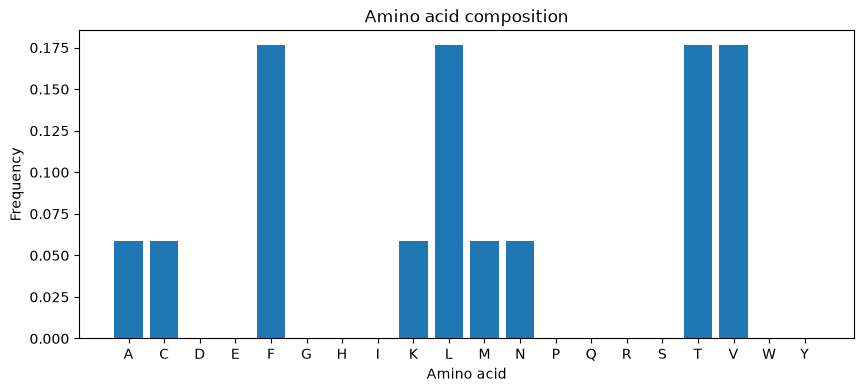

In [15]:
plt.figure(figsize=(10, 4))
plt.bar(freq_table["amino_acid"], freq_table["frequency"])
plt.xlabel("Amino acid")
plt.ylabel("Frequency")
plt.title("Amino acid composition")
plt.show()

## 5. Simple physicochemical residue groups

Before using specialized descriptor libraries, we can define simple residue groups based on common biochemical properties.

These groups are approximations, but they are useful for teaching how biological knowledge can become numerical features.

| Group | Residues | Meaning |
|---|---|---|
| Hydrophobic | A, V, I, L, M, F, W, Y | Tend to avoid water and often contribute to cores or membranes |
| Polar uncharged | S, T, N, Q, C | Can participate in hydrogen bonding |
| Positively charged | K, R, H | Tend to carry positive charge near physiological pH |
| Negatively charged | D, E | Tend to carry negative charge near physiological pH |
| Special/conformational | G, P | Often influence flexibility or local structure |
| Aromatic | F, W, Y | Contain aromatic rings |
| Aliphatic | A, I, L, V | Used in the classical aliphatic index definition |

In [16]:
RESIDUE_GROUPS = {
    "hydrophobic": set("AVILMFWY"),
    "polar_uncharged": set("STNQC"),
    "positive": set("KRH"),
    "negative": set("DE"),
    "special": set("GP"),
    "aromatic": set("FWY"),
    "aliphatic": set("AILV"),
}


def residue_group_fraction(sequence, residues):
    """Fraction of residues belonging to a selected residue group."""
    sequence = sequence.upper()
    return sum(1 for aa in sequence if aa in residues) / len(sequence)


def residue_group_features(sequence):
    """Return simple residue-group composition features."""
    return {
        f"{group}_fraction": residue_group_fraction(sequence, residues)
        for group, residues in RESIDUE_GROUPS.items()
    }

residue_group_features(protein)

{'hydrophobic_fraction': 0.6470588235294118,
 'polar_uncharged_fraction': 0.29411764705882354,
 'positive_fraction': 0.058823529411764705,
 'negative_fraction': 0.0,
 'special_fraction': 0.0,
 'aromatic_fraction': 0.17647058823529413,
 'aliphatic_fraction': 0.4117647058823529}

## 6. Manual physicochemical descriptors

Here we define a small set of estimated descriptors.

These are useful because they make the idea of descriptors transparent before using a package.

### Descriptor definitions

| Descriptor | Definition | Interpretation |
|---|---|---|
| Length | Number of amino acids | Sequence size |
| Molecular weight | Approximate mass in Daltons | Larger proteins tend to have higher mass |
| Net charge | Estimated electrical charge at a given pH | Important for solubility and interactions |
| Charge density | Net charge divided by molecular weight | Charge normalized by size |
| Isoelectric point | pH at which the estimated net charge is close to zero | Useful for solubility and separation |
| Hydrophobic fraction | Fraction of hydrophobic residues | Related to membrane interaction, aggregation, or cores |
| Aromaticity | Fraction of F, W, Y | Relative abundance of aromatic residues |
| Aliphatic index | Approximate index based on A, V, I, L | Often associated with thermostability trends |

> These functions are simplified. Later, `modlamp` will be used for a standardized descriptor implementation.

In [17]:
# Average residue masses after peptide bond formation, in Daltons.
# These are residue masses, not free amino acid masses.
AA_MASS = {
    "A": 71.0788, "C": 103.1388, "D": 115.0886, "E": 129.1155,
    "F": 147.1766, "G": 57.0519, "H": 137.1411, "I": 113.1594,
    "K": 128.1741, "L": 113.1594, "M": 131.1926, "N": 114.1038,
    "P": 97.1167, "Q": 128.1307, "R": 156.1875, "S": 87.0782,
    "T": 101.1051, "V": 99.1326, "W": 186.2132, "Y": 163.1760,
}

WATER_MASS = 18.01528

# pKa values used for a simple Henderson-Hasselbalch charge approximation.
PKA_POSITIVE = {"Nterm": 9.38, "K": 10.67, "R": 12.10, "H": 6.04}
PKA_NEGATIVE = {"Cterm": 2.15, "D": 3.71, "E": 4.15, "C": 8.14, "Y": 10.10}


def molecular_weight(sequence):
    """Approximate molecular weight using residue masses plus one water molecule."""
    sequence = sequence.upper()
    return sum(AA_MASS[aa] for aa in sequence) + WATER_MASS


def net_charge(sequence, ph=7.4):
    """Approximate net charge at a given pH using Henderson-Hasselbalch equations."""
    sequence = sequence.upper()
    counts = Counter(sequence)

    positive = 0.0
    positive += 1 / (1 + 10 ** (ph - PKA_POSITIVE["Nterm"]))
    positive += counts["K"] / (1 + 10 ** (ph - PKA_POSITIVE["K"]))
    positive += counts["R"] / (1 + 10 ** (ph - PKA_POSITIVE["R"]))
    positive += counts["H"] / (1 + 10 ** (ph - PKA_POSITIVE["H"]))

    negative = 0.0
    negative += 1 / (1 + 10 ** (PKA_NEGATIVE["Cterm"] - ph))
    negative += counts["D"] / (1 + 10 ** (PKA_NEGATIVE["D"] - ph))
    negative += counts["E"] / (1 + 10 ** (PKA_NEGATIVE["E"] - ph))
    negative += counts["C"] / (1 + 10 ** (PKA_NEGATIVE["C"] - ph))
    negative += counts["Y"] / (1 + 10 ** (PKA_NEGATIVE["Y"] - ph))

    return positive - negative


def charge_density(sequence, ph=7.4):
    """Net charge normalized by molecular weight."""
    return net_charge(sequence, ph=ph) / molecular_weight(sequence)


def approximate_isoelectric_point(sequence, lower=0.0, upper=14.0, tolerance=1e-4, max_iter=100):
    """Approximate pI by binary search for pH where net charge is near zero."""
    low, high = lower, upper
    for _ in range(max_iter):
        mid = (low + high) / 2
        charge = net_charge(sequence, ph=mid)
        if abs(charge) < tolerance:
            return mid
        if charge > 0:
            low = mid
        else:
            high = mid
    return (low + high) / 2


def aromaticity(sequence):
    return residue_group_fraction(sequence, RESIDUE_GROUPS["aromatic"])


def hydrophobic_fraction(sequence):
    return residue_group_fraction(sequence, RESIDUE_GROUPS["hydrophobic"])


def aliphatic_index(sequence):
    """Approximate Ikai aliphatic index: X(Ala) + 2.9*X(Val) + 3.9*(X(Ile)+X(Leu))."""
    freqs = amino_acid_frequencies(sequence)
    return 100 * (freqs["A"] + 2.9 * freqs["V"] + 3.9 * (freqs["I"] + freqs["L"]))


def manual_physicochemical_features(sequence, ph=7.4):
    """Compute a compact set of manual physicochemical descriptors."""
    return {
        "length": len(sequence),
        "MW_approx_Da": molecular_weight(sequence),
        "net_charge_pH_7_4": net_charge(sequence, ph=ph),
        "charge_density_pH_7_4": charge_density(sequence, ph=ph),
        "pI_approx": approximate_isoelectric_point(sequence),
        "hydrophobic_fraction": hydrophobic_fraction(sequence),
        "aromaticity": aromaticity(sequence),
        "aliphatic_index_approx": aliphatic_index(sequence),
    }

manual_physicochemical_features(protein)

{'length': 17,
 'MW_approx_Da': 1947.4244800000001,
 'net_charge_pH_7_4': 0.8351512063492461,
 'charge_density_pH_7_4': 0.00042884908499725037,
 'pI_approx': 8.74359130859375,
 'hydrophobic_fraction': 0.6470588235294118,
 'aromaticity': 0.17647058823529413,
 'aliphatic_index_approx': 125.88235294117646}

## 7. Physicochemical descriptors with `modlamp`

`modlamp` is a Python package designed for working with peptides, proteins, or amino acid sequences.  
For descriptor calculation, its two main classes are:

- `GlobalDescriptor`: global one-dimensional descriptors calculated from amino acid sequences.
- `PeptideDescriptor`: descriptors based on amino acid property scales.

The `GlobalDescriptor.calculate_all()` method returns several global descriptors, including:

```text
Length, molecular weight, charge, charge density, pI,
instability index, aromaticity, aliphatic index,
Boman index, hydrophobic ratio
```

### Descriptor definitions used by `modlamp`

| Descriptor | Simple meaning |
|---|---|
| Length | Number of amino acids |
| MW | Molecular weight |
| Charge | Estimated net charge at selected pH |
| ChargeDensity | Charge normalized by molecular weight |
| pI | Isoelectric point |
| InstabilityInd | Composition-based estimate of sequence instability |
| Aromaticity | Relative frequency of F, W, and Y |
| AliphaticInd | Index based on aliphatic residues A, V, I, and L |
| BomanInd | Estimate related to protein-binding potential |
| HydrophRatio | Relative frequency of hydrophobic residues |

> If `modlamp` is not installed, this notebook will return manual fallback descriptors for the features we implemented above.

In [18]:
def modlamp_global_descriptors(sequences, names=None, ph=7.4, amide=True):
    """Calculate global descriptors using modlamp when available.

    If modlamp is unavailable, returns manual fallback descriptors.
    """
    if isinstance(sequences, str):
        sequences = [sequences]

    if names is None:
        names = [f"seq_{i+1}" for i in range(len(sequences))]

    if MODLAMP_AVAILABLE:
        desc = GlobalDescriptor(sequences)
        desc.calculate_all(ph=ph, amide=amide)
        df = pd.DataFrame(desc.descriptor, columns=desc.featurenames)
        df.insert(0, "sample_id", names)
        return df

    warnings.warn(
        "modlamp is not installed. Returning manual fallback descriptors instead. "
        "Install modlamp with `%pip install modlamp` for the standardized implementation."
    )
    rows = []
    for sample_id, seq in zip(names, sequences):
        row = {"sample_id": sample_id}
        row.update(manual_physicochemical_features(seq, ph=ph))
        rows.append(row)
    return pd.DataFrame(rows)

modlamp_global_descriptors(protein, names=["protein_example"])

,sample_id,Length,MW,Charge,ChargeDensity,pI,InstabilityInd,Aromaticity,AliphaticInd,BomanInd,HydrophRatio
0,protein_example,17.0,1946.43,1.835,0.000943,10.042969,43.105882,0.176471,125.882353,-1.256471,0.705882


## 8. Amino acid property scales

A protein sequence can also be represented by mapping each amino acid to a numerical property value.

For example, the Kyte-Doolittle hydrophobicity scale assigns a hydrophobicity value to each amino acid.  
After mapping the sequence to numbers, we can compute summary descriptors such as:

- mean property value
- standard deviation
- minimum and maximum
- property range
- local profiles with sliding windows

This is the same general idea behind many amino acid scale-based descriptors.

In [19]:
# Kyte-Doolittle hydrophobicity scale.
KYTE_DOOLITTLE = {
    "I": 4.5, "V": 4.2, "L": 3.8, "F": 2.8, "C": 2.5,
    "M": 1.9, "A": 1.8, "G": -0.4, "T": -0.7, "S": -0.8,
    "W": -0.9, "Y": -1.3, "P": -1.6, "H": -3.2, "E": -3.5,
    "Q": -3.5, "D": -3.5, "N": -3.5, "K": -3.9, "R": -4.5,
}

# Simple residue charge scale at neutral pH.
SIMPLE_CHARGE_SCALE = {
    aa: (1 if aa in set("KRH") else -1 if aa in set("DE") else 0)
    for aa in AMINO_ACIDS
}


def sequence_to_property_values(sequence, scale):
    """Map a protein sequence to numerical values using an amino acid property scale."""
    return np.array([scale[aa] for aa in sequence.upper()], dtype=float)


def property_summary(sequence, scale, prefix):
    """Summarize a sequence after mapping amino acids to a property scale."""
    values = sequence_to_property_values(sequence, scale)
    return {
        f"{prefix}_mean": np.mean(values),
        f"{prefix}_std": np.std(values),
        f"{prefix}_min": np.min(values),
        f"{prefix}_max": np.max(values),
        f"{prefix}_range": np.max(values) - np.min(values),
    }

property_summary(protein, KYTE_DOOLITTLE, "hydrophobicity")

{'hydrophobicity_mean': np.float64(1.7117647058823529),
 'hydrophobicity_std': np.float64(2.566499642553046),
 'hydrophobicity_min': np.float64(-3.9),
 'hydrophobicity_max': np.float64(4.2),
 'hydrophobicity_range': np.float64(8.1)}

In [20]:
property_summary(protein, SIMPLE_CHARGE_SCALE, "simple_charge")

{'simple_charge_mean': np.float64(0.058823529411764705),
 'simple_charge_std': np.float64(0.23529411764705885),
 'simple_charge_min': np.float64(0.0),
 'simple_charge_max': np.float64(1.0),
 'simple_charge_range': np.float64(1.0)}

### 8.1 Sliding-window property profiles

A **property profile** describes how a property changes along the sequence.

For example, a hydrophobicity profile can highlight hydrophobic regions that may correspond to membrane-associated segments or hydrophobic cores.

In [21]:
def sliding_window_mean(values, window=5):
    """Compute sliding-window means for a numerical sequence."""
    if window > len(values):
        return np.array([np.mean(values)])
    return np.array([
        np.mean(values[i:i+window])
        for i in range(len(values) - window + 1)
    ])

hydrophobicity_values = sequence_to_property_values(protein, KYTE_DOOLITTLE)
hydrophobicity_profile = sliding_window_mean(hydrophobicity_values, window=5)

hydrophobicity_profile

array([0.58, 1.04, 2.58, 3.48, 3.68, 3.62, 2.64, 2.44, 1.54, 1.62, 1.96,
       1.4 , 1.2 ])

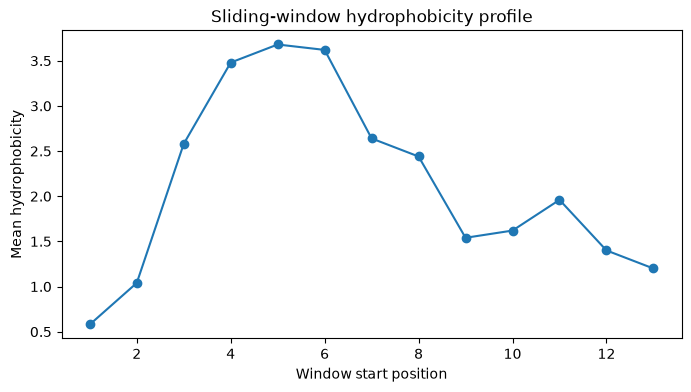

In [22]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(hydrophobicity_profile) + 1), hydrophobicity_profile, marker="o")
plt.xlabel("Window start position")
plt.ylabel("Mean hydrophobicity")
plt.title("Sliding-window hydrophobicity profile")
plt.show()

### 8.2 Property descriptors with `modlamp.PeptideDescriptor`

`PeptideDescriptor` can calculate descriptors based on amino acid property scales.  
For teaching, we will try two examples when `modlamp` is installed:

- global hydrophobicity using the Kyte-Doolittle scale
- hydrophobic moment using the Eisenberg scale

If `modlamp` is not installed, this cell returns a simple message and the notebook continues.

In [23]:
def modlamp_scale_descriptors(sequence):
    """Small example using modlamp.PeptideDescriptor when available."""
    if not MODLAMP_AVAILABLE:
        return pd.DataFrame({
            "descriptor": ["modlamp unavailable"],
            "value": [np.nan]
        })

    rows = []

    # Global Kyte-Doolittle hydrophobicity descriptor
    kd = PeptideDescriptor(sequence, "kytedoolittle")
    kd.calculate_global(window=1000, modality="mean")
    rows.append({
        "descriptor": "kytedoolittle_global_mean",
        "value": float(kd.descriptor[0][0])
    })

    # Eisenberg hydrophobic moment
    eisenberg = PeptideDescriptor(sequence, "eisenberg")
    eisenberg.calculate_moment()
    rows.append({
        "descriptor": "eisenberg_hydrophobic_moment",
        "value": float(eisenberg.descriptor[0][0])
    })

    return pd.DataFrame(rows)

modlamp_scale_descriptors(protein)

,descriptor,value
0,kytedoolittle_global_mean,0.738824
1,eisenberg_hydrophobic_moment,0.205404


## 9. Protein k-mers

A **k-mer** is a subsequence of length `k`.

For proteins, k-mers are short amino acid words.

Example:

```text
Sequence: MKTFF
k = 2 → MK, KT, TF, FF
k = 3 → MKT, KTF, TFF
```

The number of possible protein k-mers grows quickly:

```text
20^1 = 20
20^2 = 400
20^3 = 8000
20^4 = 160000
```

This is an important example of high-dimensional biological representation.

In [24]:
def get_kmers(sequence, k):
    """Return all overlapping k-mers from a sequence."""
    sequence = sequence.upper()
    if k <= 0:
        raise ValueError("k must be a positive integer")
    if k > len(sequence):
        return []
    return [sequence[i:i+k] for i in range(len(sequence) - k + 1)]

print(get_kmers("MKTFF", k=2))
print(get_kmers("MKTFF", k=3))

['MK', 'KT', 'TF', 'FF']
['MKT', 'KTF', 'TFF']


In [25]:
for k in [1, 2, 3, 4]:
    print(f"Possible protein {k}-mers: {20 ** k}")

Possible protein 1-mers: 20
Possible protein 2-mers: 400
Possible protein 3-mers: 8000
Possible protein 4-mers: 160000


### 9.1 Counting protein k-mers

A sequence can be represented by the counts of its k-mers.

In [26]:
k = 2
protein_kmers = get_kmers(protein, k=k)
kmer_counts = Counter(protein_kmers)
kmer_counts

Counter({'TF': 2,
         'LL': 2,
         'MK': 1,
         'KT': 1,
         'FF': 1,
         'FV': 1,
         'VL': 1,
         'LC': 1,
         'CT': 1,
         'FT': 1,
         'TV': 1,
         'VV': 1,
         'VN': 1,
         'NA': 1})

In [27]:
kmer_count_table = pd.DataFrame(
    sorted(kmer_counts.items()),
    columns=["kmer", "count"]
)

kmer_count_table

,kmer,count
0,CT,1
1,FF,1
2,FT,1
3,FV,1
4,KT,1
5,LC,1
6,LL,2
7,MK,1
8,NA,1
9,TF,2


### 9.2 k-mer frequency profiles

As with amino acid composition, k-mer counts can be normalized by the total number of k-mers.

In [28]:
def kmer_frequencies(sequence, k):
    kmers = get_kmers(sequence, k=k)
    counts = Counter(kmers)
    total = len(kmers)
    return {kmer: count / total for kmer, count in counts.items()}

kmer_frequencies(protein, k=2)

{'MK': 0.0625,
 'KT': 0.0625,
 'TF': 0.125,
 'FF': 0.0625,
 'FV': 0.0625,
 'VL': 0.0625,
 'LL': 0.125,
 'LC': 0.0625,
 'CT': 0.0625,
 'FT': 0.0625,
 'TV': 0.0625,
 'VV': 0.0625,
 'VN': 0.0625,
 'NA': 0.0625}

## 10. k-mer vectors

To compare multiple sequences, all sequences must be represented using the same columns.

This requires a **fixed vocabulary**.

For proteins, a full 2-mer vocabulary contains 400 possible columns.  
For teaching, we can also use the **observed vocabulary**, meaning only k-mers observed in our small dataset.

In [29]:
def observed_kmer_vocabulary(sequences, k):
    vocab = set()
    for seq in sequences:
        vocab.update(get_kmers(seq, k=k))
    return sorted(vocab)


def kmer_vector(sequence, k, vocabulary, normalize=False):
    counts = Counter(get_kmers(sequence, k=k))
    vector = np.array([counts[kmer] for kmer in vocabulary], dtype=float)
    if normalize and vector.sum() > 0:
        vector = vector / vector.sum()
    return vector

vocabulary = observed_kmer_vocabulary([protein], k=2)
vector = kmer_vector(protein, k=2, vocabulary=vocabulary, normalize=False)

pd.DataFrame([vector], columns=vocabulary)

,CT,FF,FT,FV,KT,LC,LL,MK,NA,TF,TV,VL,VN,VV
0,1.0,1.0,1.0,1.0,1.0,1.0,2.0,1.0,1.0,2.0,1.0,1.0,1.0,1.0


## 11. Entropy and sequence complexity descriptors

Entropy-based descriptors summarize how diverse or repetitive a sequence is.

### 11.1 Shannon entropy

For amino acid frequencies `p_i`, Shannon entropy is:

```text
H = - Σ p_i log2(p_i)
```

Interpretation:

- Low entropy: the sequence is dominated by few amino acids.
- High entropy: the sequence uses many amino acids more evenly.

### 11.2 Normalized entropy

Raw amino acid entropy ranges from 0 to log2(20).  
To obtain a value between 0 and 1:

```text
H_normalized = H / log2(20)
```

### 11.3 Gini impurity

Gini impurity is:

```text
Gini = 1 - Σ p_i²
```

Interpretation:

- Low Gini: composition is concentrated in few symbols.
- High Gini: composition is more diverse.

### 11.4 Simpson concentration

Simpson concentration is:

```text
Simpson = Σ p_i²
```

Interpretation:

- High Simpson concentration: one or few residues dominate.
- Low Simpson concentration: more even composition.

### 11.5 k-mer entropy

The same entropy idea can be applied to k-mer frequencies instead of amino acid frequencies.

In [30]:
def shannon_entropy_from_probabilities(probabilities):
    """Compute Shannon entropy from a list or array of probabilities."""
    probs = np.array(probabilities, dtype=float)
    probs = probs[probs > 0]
    return -np.sum(probs * np.log2(probs))


def amino_acid_entropy(sequence):
    freqs = amino_acid_frequencies(sequence)
    return shannon_entropy_from_probabilities(list(freqs.values()))


def normalized_amino_acid_entropy(sequence):
    return amino_acid_entropy(sequence) / math.log2(20)


def gini_impurity_from_probabilities(probabilities):
    probs = np.array(probabilities, dtype=float)
    return 1 - np.sum(probs ** 2)


def simpson_concentration_from_probabilities(probabilities):
    probs = np.array(probabilities, dtype=float)
    return np.sum(probs ** 2)


def amino_acid_gini(sequence):
    freqs = amino_acid_frequencies(sequence)
    return gini_impurity_from_probabilities(list(freqs.values()))


def amino_acid_simpson(sequence):
    freqs = amino_acid_frequencies(sequence)
    return simpson_concentration_from_probabilities(list(freqs.values()))


def kmer_entropy(sequence, k):
    freqs = kmer_frequencies(sequence, k=k)
    return shannon_entropy_from_probabilities(list(freqs.values()))


def normalized_kmer_entropy(sequence, k):
    max_entropy = math.log2(min(20 ** k, max(len(sequence) - k + 1, 1)))
    if max_entropy == 0:
        return 0.0
    return kmer_entropy(sequence, k=k) / max_entropy

entropy_features = {
    "aa_entropy": amino_acid_entropy(protein),
    "aa_entropy_normalized": normalized_amino_acid_entropy(protein),
    "aa_gini": amino_acid_gini(protein),
    "aa_simpson": amino_acid_simpson(protein),
    "kmer2_entropy": kmer_entropy(protein, k=2),
    "kmer2_entropy_normalized": normalized_kmer_entropy(protein, k=2),
}

entropy_features

{'aa_entropy': np.float64(2.9686657819177587),
 'aa_entropy_normalized': np.float64(0.6868845840886503),
 'aa_gini': np.float64(0.8581314878892734),
 'aa_simpson': np.float64(0.14186851211072665),
 'kmer2_entropy': np.float64(3.75),
 'kmer2_entropy_normalized': np.float64(0.9375)}

### 11.6 Residue-group entropy

Instead of computing entropy over the 20 amino acids, we can compute entropy over residue groups.

This gives a coarser view of sequence diversity:

```text
hydrophobic / polar / positive / negative / special
```

In [31]:
GROUP_CLASSIFICATION = {
    "hydrophobic": set("AVILMFWY"),
    "polar_uncharged": set("STNQC"),
    "positive": set("KRH"),
    "negative": set("DE"),
    "special": set("GP"),
}


def residue_group_label(aa):
    for group, residues in GROUP_CLASSIFICATION.items():
        if aa in residues:
            return group
    return "other"


def group_frequencies(sequence):
    labels = [residue_group_label(aa) for aa in sequence.upper()]
    counts = Counter(labels)
    total = len(labels)
    return {group: counts[group] / total for group in GROUP_CLASSIFICATION}


def group_entropy(sequence):
    freqs = group_frequencies(sequence)
    return shannon_entropy_from_probabilities(list(freqs.values()))


def normalized_group_entropy(sequence):
    return group_entropy(sequence) / math.log2(len(GROUP_CLASSIFICATION))

pd.DataFrame([group_frequencies(protein)])

,hydrophobic,polar_uncharged,positive,negative,special
0,0.647059,0.294118,0.058824,0.0,0.0


In [32]:
print("Group entropy:", group_entropy(protein))
print("Normalized group entropy:", normalized_group_entropy(protein))

Group entropy: 1.1660870601063933
Normalized group entropy: 0.5022063614605433


### 11.7 Repetition and low-complexity descriptors

Some sequences contain repeated residues or repeated short motifs.

Simple repetition descriptors include:

| Descriptor | Definition |
|---|---|
| Max residue frequency | Frequency of the most common amino acid |
| Top-2 residue frequency | Combined frequency of the two most common amino acids |
| Longest homopolymer run | Longest consecutive run of the same amino acid |
| Unique amino acid count | Number of different amino acids used |
| Unique k-mer count | Number of different k-mers observed |

These descriptors help identify low-complexity sequences.

In [33]:
def longest_homopolymer_run(sequence):
    """Return the length of the longest consecutive run of the same amino acid."""
    if not sequence:
        return 0
    max_run = 1
    current_run = 1
    for i in range(1, len(sequence)):
        if sequence[i] == sequence[i - 1]:
            current_run += 1
            max_run = max(max_run, current_run)
        else:
            current_run = 1
    return max_run


def low_complexity_features(sequence, k=2):
    counts = Counter(sequence)
    total = len(sequence)
    sorted_freqs = sorted([count / total for count in counts.values()], reverse=True)
    kmers = get_kmers(sequence, k=k)

    return {
        "unique_aa_count": len(counts),
        "max_residue_frequency": sorted_freqs[0],
        "top2_residue_frequency": sum(sorted_freqs[:2]),
        "longest_homopolymer_run": longest_homopolymer_run(sequence),
        f"unique_{k}mer_count": len(set(kmers)),
    }

low_complexity_features(protein, k=2)

{'unique_aa_count': 9,
 'max_residue_frequency': 0.17647058823529413,
 'top2_residue_frequency': 0.35294117647058826,
 'longest_homopolymer_run': 3,
 'unique_2mer_count': 14}

## 12. One function to extract protein features

Now we combine several descriptors into one feature extraction function.

The output is a dictionary that can become one row in a feature matrix.

In [34]:
def extract_protein_features(sequence, ph=7.4, entropy_k=2):
    """Extract a compact set of protein sequence features."""
    sequence = sequence.upper()

    features = {}
    features.update(manual_physicochemical_features(sequence, ph=ph))
    features.update(residue_group_features(sequence))
    features.update(property_summary(sequence, KYTE_DOOLITTLE, "hydrophobicity"))
    features.update(property_summary(sequence, SIMPLE_CHARGE_SCALE, "simple_charge"))
    features.update({
        "aa_entropy": amino_acid_entropy(sequence),
        "aa_entropy_normalized": normalized_amino_acid_entropy(sequence),
        "aa_gini": amino_acid_gini(sequence),
        "aa_simpson": amino_acid_simpson(sequence),
        f"kmer{entropy_k}_entropy": kmer_entropy(sequence, k=entropy_k),
        f"kmer{entropy_k}_entropy_normalized": normalized_kmer_entropy(sequence, k=entropy_k),
        "group_entropy": group_entropy(sequence),
        "group_entropy_normalized": normalized_group_entropy(sequence),
    })
    features.update(low_complexity_features(sequence, k=entropy_k))

    return features

extract_protein_features(protein)

{'length': 17,
 'MW_approx_Da': 1947.4244800000001,
 'net_charge_pH_7_4': 0.8351512063492461,
 'charge_density_pH_7_4': 0.00042884908499725037,
 'pI_approx': 8.74359130859375,
 'hydrophobic_fraction': 0.6470588235294118,
 'aromaticity': 0.17647058823529413,
 'aliphatic_index_approx': 125.88235294117646,
 'polar_uncharged_fraction': 0.29411764705882354,
 'positive_fraction': 0.058823529411764705,
 'negative_fraction': 0.0,
 'special_fraction': 0.0,
 'aromatic_fraction': 0.17647058823529413,
 'aliphatic_fraction': 0.4117647058823529,
 'hydrophobicity_mean': np.float64(1.7117647058823529),
 'hydrophobicity_std': np.float64(2.566499642553046),
 'hydrophobicity_min': np.float64(-3.9),
 'hydrophobicity_max': np.float64(4.2),
 'hydrophobicity_range': np.float64(8.1),
 'simple_charge_mean': np.float64(0.058823529411764705),
 'simple_charge_std': np.float64(0.23529411764705885),
 'simple_charge_min': np.float64(0.0),
 'simple_charge_max': np.float64(1.0),
 'simple_charge_range': np.float64(1.0)

## 13. Multiple protein sequences as a dataset

Now we create a small synthetic dataset.

Each row represents one sequence.

The labels are only illustrative. They are not experimentally validated.

In [35]:
protein_samples = {
    "PEP001": "MKTFFVLLLCTFTVVNA",
    "PEP002": "KKLLKLLKKLLKLLKK",
    "PEP003": "DEDEDEDEDEDEDEDE",
    "PEP004": "GPGPGPGPGPGPGPGP",
    "PEP005": "ACDEFGHIKLMNPQRSTVWY",
    "PEP006": "WFWKWWRRRRKKFFFW",
}

metadata = pd.DataFrame({
    "sample_id": list(protein_samples.keys()),
    "toy_group": [
        "hydrophobic_signal_like",
        "cationic_hydrophobic",
        "acidic_low_complexity",
        "proline_glycine_repetitive",
        "balanced_composition",
        "aromatic_cationic",
    ]
})

metadata

,sample_id,toy_group
0,PEP001,hydrophobic_signal_like
1,PEP002,cationic_hydrophobic
2,PEP003,acidic_low_complexity
3,PEP004,proline_glycine_repetitive
4,PEP005,balanced_composition
5,PEP006,aromatic_cationic


In [36]:
feature_rows = []
for sample_id, seq in protein_samples.items():
    row = {"sample_id": sample_id, "sequence": seq}
    row.update(extract_protein_features(seq))
    feature_rows.append(row)

protein_feature_table = pd.DataFrame(feature_rows)
protein_feature_table = metadata.merge(protein_feature_table, on="sample_id")

protein_feature_table

,sample_id,toy_group,sequence,length,MW_approx_Da,net_charge_pH_7_4,charge_density_pH_7_4,pI_approx,hydrophobic_fraction,aromaticity,aliphatic_index_approx,polar_uncharged_fraction,positive_fraction,negative_fraction,special_fraction,aromatic_fraction,aliphatic_fraction,hydrophobicity_mean,hydrophobicity_std,hydrophobicity_min,hydrophobicity_max,hydrophobicity_range,simple_charge_mean,simple_charge_std,simple_charge_min,simple_charge_max,simple_charge_range,aa_entropy,aa_entropy_normalized,aa_gini,aa_simpson,kmer2_entropy,kmer2_entropy_normalized,group_entropy,group_entropy_normalized,unique_aa_count,max_residue_frequency,top2_residue_frequency,longest_homopolymer_run,unique_2mer_count
0,PEP001,hydrophobic_signal_like,MKTFFVLLLCTFTVVNA,17,1947.42448,0.835151,0.000429,8.743591,0.647059,0.176471,125.882353,0.294118,0.058824,0.0,0.0,0.176471,0.411765,1.711765,2.566500,-3.9,4.2,8.1,0.058824,0.235294,0.0,1.0,1.0,2.968666,0.686885,0.858131,0.141869,3.750000,0.937500,1.166087,0.502206,9,0.176471,0.352941,3,14
1,PEP002,cationic_hydrophobic,KKLLKLLKKLLKLLKK,16,1948.68328,7.985349,0.004098,11.518661,0.500000,0.000000,195.000000,0.000000,0.500000,0.0,0.0,0.000000,0.500000,-0.050000,3.850000,-3.9,3.8,7.7,0.500000,0.500000,0.0,1.0,1.0,1.000000,0.231378,0.500000,0.500000,1.989898,0.509330,1.000000,0.430677,2,0.500000,1.000000,2,4
2,PEP003,acidic_low_complexity,DEDEDEDEDEDEDEDE,16,1971.64808,-16.004228,-0.008117,2.302429,0.000000,0.000000,0.000000,0.000000,0.000000,1.0,0.0,0.000000,0.000000,-3.500000,0.000000,-3.5,-3.5,0.0,-1.000000,0.000000,-1.0,-1.0,0.0,1.000000,0.231378,0.500000,0.500000,0.996792,0.255137,-0.000000,-0.000000,2,0.500000,1.000000,1,2
3,PEP004,proline_glycine_repetitive,GPGPGPGPGPGPGPGP,16,1251.36408,-0.010357,-0.000008,5.687500,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,1.0,0.000000,0.000000,-1.000000,0.600000,-1.6,-0.4,1.2,0.000000,0.000000,0.0,0.0,0.0,1.000000,0.231378,0.500000,0.500000,0.996792,0.255137,-0.000000,-0.000000,2,0.500000,1.000000,1,2
4,PEP005,balanced_composition,ACDEFGHIKLMNPQRSTVWY,20,2395.73588,-0.124268,-0.000052,7.076904,0.400000,0.150000,58.500000,0.250000,0.150000,0.1,0.1,0.150000,0.200000,-0.490000,2.911340,-4.5,4.5,9.0,0.050000,0.497494,-1.0,1.0,2.0,4.321928,1.000000,0.950000,0.050000,4.247928,1.000000,2.103702,0.906015,20,0.050000,0.100000,1,19
5,PEP006,aromatic_cationic,WFWKWWRRRRKKFFFW,16,2547.05998,6.987953,0.002744,12.597992,0.562500,0.562500,0.000000,0.000000,0.437500,0.0,0.0,0.562500,0.000000,-1.437500,2.839207,-4.5,2.8,7.3,0.437500,0.496078,0.0,1.0,1.0,1.977217,0.457485,0.742188,0.257812,3.323231,0.850608,0.988699,0.425810,4,0.312500,0.562500,4,11


### 13.1 Selected feature view

The full feature table contains many columns.  
For teaching, we can display a smaller subset.

In [37]:
selected_features = [
    "sample_id", "toy_group", "length", "MW_approx_Da", "net_charge_pH_7_4",
    "hydrophobic_fraction", "aromaticity", "aliphatic_index_approx",
    "aa_entropy_normalized", "group_entropy_normalized",
    "max_residue_frequency", "longest_homopolymer_run"
]

protein_feature_table[selected_features]

,sample_id,toy_group,length,MW_approx_Da,net_charge_pH_7_4,hydrophobic_fraction,aromaticity,aliphatic_index_approx,aa_entropy_normalized,group_entropy_normalized,max_residue_frequency,longest_homopolymer_run
0,PEP001,hydrophobic_signal_like,17,1947.42448,0.835151,0.647059,0.176471,125.882353,0.686885,0.502206,0.176471,3
1,PEP002,cationic_hydrophobic,16,1948.68328,7.985349,0.500000,0.000000,195.000000,0.231378,0.430677,0.500000,2
2,PEP003,acidic_low_complexity,16,1971.64808,-16.004228,0.000000,0.000000,0.000000,0.231378,-0.000000,0.500000,1
3,PEP004,proline_glycine_repetitive,16,1251.36408,-0.010357,0.000000,0.000000,0.000000,0.231378,-0.000000,0.500000,1
4,PEP005,balanced_composition,20,2395.73588,-0.124268,0.400000,0.150000,58.500000,1.000000,0.906015,0.050000,1
5,PEP006,aromatic_cationic,16,2547.05998,6.987953,0.562500,0.562500,0.000000,0.457485,0.425810,0.312500,4


## 14. modlamp descriptors for multiple sequences

Here we compute global descriptors with `modlamp` if it is available.

If not available, the function returns the manual fallback descriptor table.

In [38]:
modlamp_table = modlamp_global_descriptors(
    sequences=list(protein_samples.values()),
    names=list(protein_samples.keys()),
    ph=7.4,
    amide=True
)

modlamp_table

,sample_id,Length,MW,Charge,ChargeDensity,pI,InstabilityInd,Aromaticity,AliphaticInd,BomanInd,HydrophRatio
0,PEP001,17.0,1946.43,1.835,0.000943,10.042969,43.105882,0.176471,125.882353,-1.256471,0.705882
1,PEP002,16.0,1947.68,8.985,0.004613,13.296875,-33.075000,0.000000,195.000000,0.315000,0.500000
2,PEP003,16.0,1970.65,-15.004,-0.007614,2.706543,93.637500,0.000000,0.000000,7.765000,0.000000
3,PEP004,16.0,1250.38,0.990,0.000792,12.250000,9.375000,0.000000,0.000000,-0.470000,0.000000
4,PEP005,20.0,2394.74,0.876,0.000366,8.695312,84.740000,0.150000,58.500000,1.669000,0.350000
5,PEP006,16.0,2546.04,7.988,0.003137,13.869141,116.775000,0.562500,0.000000,3.297500,0.250000


## 15. Protein k-mer matrix

Now we represent each sequence as a vector of protein 2-mer counts.

For this small example, we use the observed 2-mer vocabulary.

In [39]:
k = 2
observed_vocab = observed_kmer_vocabulary(list(protein_samples.values()), k=k)

print("Number of observed 2-mers:", len(observed_vocab))
print(observed_vocab[:20])

Number of observed 2-mers: 46
['AC', 'CD', 'CT', 'DE', 'ED', 'EF', 'FF', 'FG', 'FT', 'FV', 'FW', 'GH', 'GP', 'HI', 'IK', 'KF', 'KK', 'KL', 'KT', 'KW']


In [40]:
kmer_rows = []
for sample_id, seq in protein_samples.items():
    vector = kmer_vector(seq, k=k, vocabulary=observed_vocab, normalize=True)
    row = {"sample_id": sample_id}
    row.update({kmer: value for kmer, value in zip(observed_vocab, vector)})
    kmer_rows.append(row)

protein_kmer_matrix = pd.DataFrame(kmer_rows)
protein_kmer_matrix

,sample_id,AC,CD,CT,DE,ED,EF,FF,FG,FT,FV,FW,GH,GP,HI,IK,KF,KK,KL,KT,KW,LC,LK,LL,LM,MK,MN,NA,NP,PG,PQ,QR,RK,RR,RS,ST,TF,TV,VL,VN,VV,VW,WF,WK,WR,WW,WY
0,PEP001,0.000000,0.000000,0.0625,0.000000,0.000000,0.000000,0.062500,0.000000,0.0625,0.0625,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0625,0.000000,0.0625,0.000000,0.125000,0.000000,0.0625,0.000000,0.0625,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.125,0.062500,0.0625,0.0625,0.0625,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,PEP002,0.000000,0.000000,0.0000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.0000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.200000,0.266667,0.0000,0.000000,0.0000,0.266667,0.266667,0.000000,0.0000,0.000000,0.0000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000,0.000000,0.0000,0.0000,0.0000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,PEP003,0.000000,0.000000,0.0000,0.533333,0.466667,0.000000,0.000000,0.000000,0.0000,0.0000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000,0.0000,0.000000,0.000000,0.000000,0.0000,0.000000,0.0000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000,0.000000,0.0000,0.0000,0.0000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,PEP004,0.000000,0.000000,0.0000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.0000,0.000000,0.000000,0.533333,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000,0.0000,0.000000,0.000000,0.000000,0.0000,0.000000,0.0000,0.000000,0.466667,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000,0.000000,0.0000,0.0000,0.0000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,PEP005,0.052632,0.052632,0.0000,0.052632,0.000000,0.052632,0.000000,0.052632,0.0000,0.0000,0.000000,0.052632,0.000000,0.052632,0.052632,0.000000,0.000000,0.052632,0.0000,0.000000,0.0000,0.000000,0.000000,0.052632,0.0000,0.052632,0.0000,0.052632,0.000000,0.052632,0.052632,0.000000,0.0,0.052632,0.052632,0.000,0.052632,0.0000,0.0000,0.0000,0.052632,0.000000,0.000000,0.000000,0.000000,0.052632
5,PEP006,0.000000,0.000000,0.0000,0.000000,0.000000,0.000000,0.133333,0.000000,0.0000,0.0000,0.133333,0.000000,0.000000,0.000000,0.000000,0.066667,0.066667,0.000000,0.0000,0.066667,0.0000,0.000000,0.000000,0.000000,0.0000,0.000000,0.0000,0.000000,0.000000,0.000000,0.000000,0.066667,0.2,0.000000,0.000000,0.000,0.000000,0.0000,0.0000,0.0000,0.000000,0.066667,0.066667,0.066667,0.066667,0.000000


## 16. Comparing protein sequences with feature vectors

Once sequences are represented as numerical vectors, we can compute distances between them.

Here we use Euclidean distance on selected interpretable descriptors.

> Distance values depend heavily on feature scaling. In real workflows, standardization is usually necessary before comparing features with different units.

In [41]:
def euclidean_distance(x, y):
    x = np.array(x, dtype=float)
    y = np.array(y, dtype=float)
    return np.sqrt(np.sum((x - y) ** 2))

comparison_columns = [
    "length",
    "net_charge_pH_7_4",
    "hydrophobic_fraction",
    "aromaticity",
    "aa_entropy_normalized",
    "group_entropy_normalized",
    "max_residue_frequency",
]

X = protein_feature_table[comparison_columns].values
sample_ids = protein_feature_table["sample_id"].tolist()

# Standardize features to mean 0 and standard deviation 1.
X_scaled = (X - X.mean(axis=0)) / X.std(axis=0)

pairwise_distances = pd.DataFrame(
    np.zeros((len(sample_ids), len(sample_ids))),
    index=sample_ids,
    columns=sample_ids
)

for i in range(len(sample_ids)):
    for j in range(len(sample_ids)):
        pairwise_distances.iloc[i, j] = euclidean_distance(X_scaled[i], X_scaled[j])

pairwise_distances

,PEP001,PEP002,PEP003,PEP004,PEP005,PEP006
PEP001,0.000000,2.878375,4.527709,3.988268,2.917040,2.494453
PEP002,2.878375,0.000000,3.868803,2.580517,5.013549,3.126403
PEP003,4.527709,3.868803,0.000000,2.038284,6.041146,4.985123
PEP004,3.988268,2.580517,2.038284,0.000000,5.692102,4.130504
PEP005,2.917040,5.013549,6.041146,5.692102,0.000000,4.591051
PEP006,2.494453,3.126403,4.985123,4.130504,4.591051,0.000000


## 17. Visualizing feature space

With only two descriptors, we can plot sequences in a simple 2D feature space.

This is not a real model.  
It is a visual demonstration that sequences can become points in a numerical space.

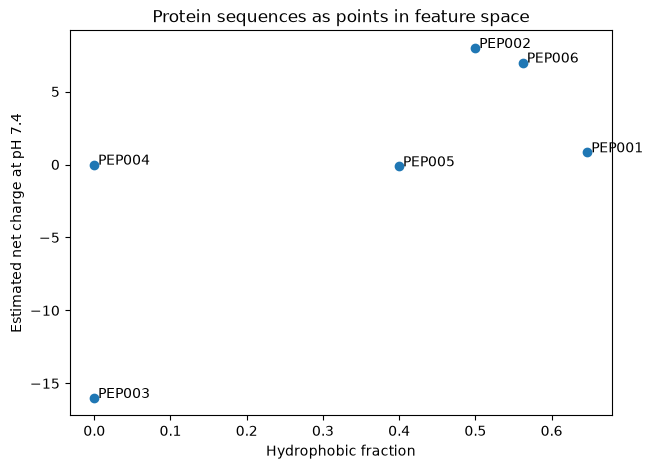

In [42]:
plt.figure(figsize=(7, 5))
plt.scatter(
    protein_feature_table["hydrophobic_fraction"],
    protein_feature_table["net_charge_pH_7_4"]
)

for _, row in protein_feature_table.iterrows():
    plt.text(row["hydrophobic_fraction"] + 0.005, row["net_charge_pH_7_4"], row["sample_id"])

plt.xlabel("Hydrophobic fraction")
plt.ylabel("Estimated net charge at pH 7.4")
plt.title("Protein sequences as points in feature space")
plt.show()

## 18. Final conceptual integration

Protein sequences can be represented in many complementary ways.

| Representation type | Example features | What it captures |
|---|---|---|
| Composition | amino acid frequencies | global residue usage |
| k-mers | dipeptide or tripeptide counts | local sequence patterns |
| Physicochemical descriptors | charge, hydrophobicity, pI, MW | biochemical properties |
| Property profiles | sliding-window hydrophobicity | local variation along sequence |
| Entropy descriptors | Shannon entropy, Gini, k-mer entropy | diversity and complexity |
| Feature matrices | rows = sequences, columns = features | machine-learning-ready data |

The key transition is:

```text
protein sequence
↓
biological symbols
↓
mathematical representation
↓
comparison, classification, clustering, modeling
```

This is the same logic used in many protein machine learning workflows.

# 19. Student exercises

## Exercise 1

Given the sequence:

```python
seq = "ACDEFGHIKLMNPQRSTVWY"
```

Compute:

1. length
2. amino acid counts
3. amino acid frequencies
4. hydrophobic fraction
5. aromaticity
6. estimated net charge at pH 7.4

---

## Exercise 2

Given the sequence:

```python
seq = "KKLLKLLKKLLKLLKK"
```

Generate:

1. all 2-mers
2. all 3-mers
3. 2-mer counts
4. 2-mer frequencies

---

## Exercise 3

Compare the entropy of these sequences:

```python
seq_a = "AAAAAAAAAAAAAAAA"
seq_b = "ACDEFGHIKLMNPQRS"
seq_c = "GPGPGPGPGPGPGPGP"
```

Questions:

1. Which sequence has the lowest amino acid entropy?
2. Which sequence has the highest amino acid entropy?
3. How does entropy relate to sequence complexity?

---

## Exercise 4

Build a feature table for these sequences:

```python
exercise_sequences = {
    "S1": "MKTFFVLLLCTFTVVNA",
    "S2": "KKLLKLLKKLLKLLKK",
    "S3": "DEDEDEDEDEDEDEDE",
    "S4": "ACDEFGHIKLMNPQRSTVWY"
}
```

The table should include:

- sample ID
- length
- molecular weight
- net charge at pH 7.4
- hydrophobic fraction
- amino acid entropy
- normalized amino acid entropy

---

## Exercise 5

Use the same sequences from Exercise 4 and build a normalized 2-mer matrix.

Questions:

1. How many unique 2-mers are observed?
2. Which sequence has the most repetitive 2-mer profile?
3. Why does the full 2-mer vocabulary contain 400 possible features?